# testing masking functions on plane wave

0.20202020202020243


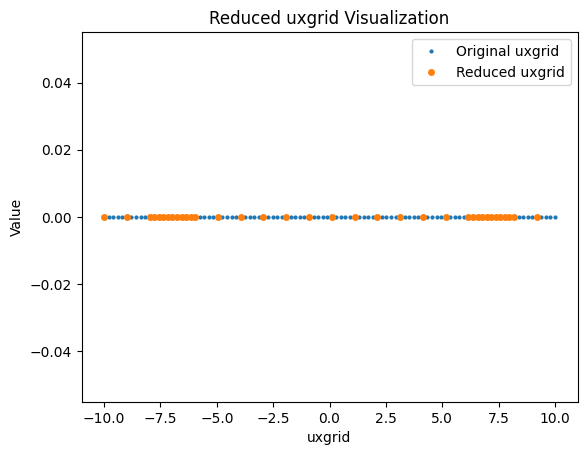

In [2]:
import numpy as np
import matplotlib.pyplot as plt

uxgrid_num = 100
uxgrid = np.linspace(-10, 10, uxgrid_num)
uxgrid_dx = uxgrid[1]-uxgrid[0]
print(uxgrid_dx)

# Desired number of points
desired_points = 20

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Highlighted ranges
highlight_ranges = [(-8, -6), (6, 8)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

mask += mask_highlight_ranges

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

In [3]:
t_start=0
t_stop=12.0
utgrid_dt=0.1
utgrid=np.arange(t_start,t_stop,utgrid_dt)

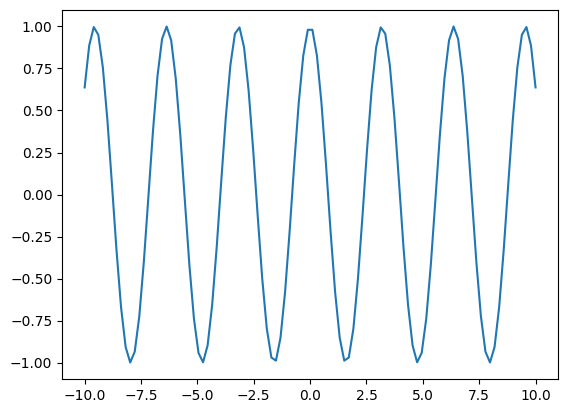

In [4]:
import quantum_toolkit as quat

k_pw = 2

dispersion=quat.Dispersion(uxgrid_dx)

wave_function = quat.plane_wave(dispersion.k2omega(k_pw), uxgrid)

plt.plot(uxgrid, np.real(wave_function['value']))


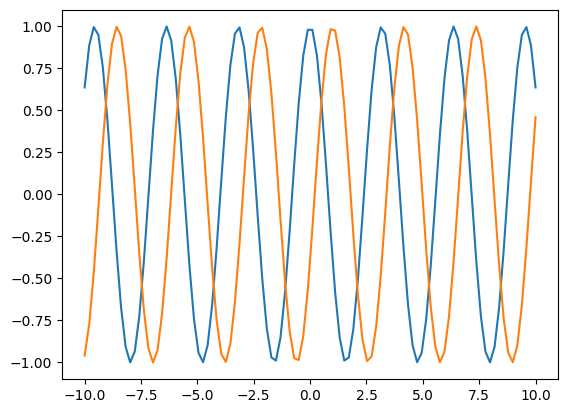

In [5]:
te_wave_function = quat.stationary_time_evolution(dispersion.k2omega(k_pw), utgrid, wave_function)

plt.plot(uxgrid, np.real(te_wave_function['value'][:,0]))
plt.plot(uxgrid, np.real(te_wave_function['value'][:,10])) 

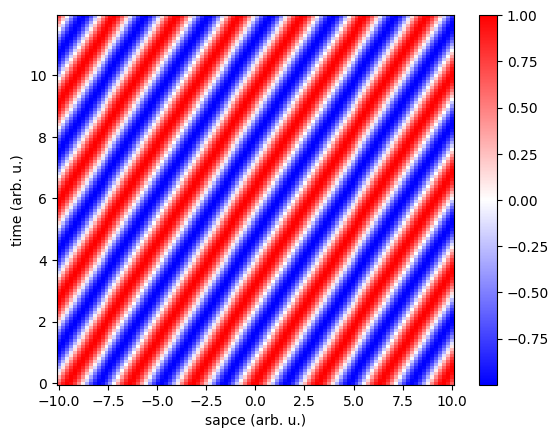

In [6]:
X,Y = np.meshgrid(uxgrid,utgrid)

Z=np.transpose(np.real(te_wave_function['value']))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)
 
#plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.xlim([-0.8*modelpot.wellwidth, 0.8*modelpot.wellwidth])
#plt.ylim(0,2*laserpot_cep0.temporal_width)
plt.show()

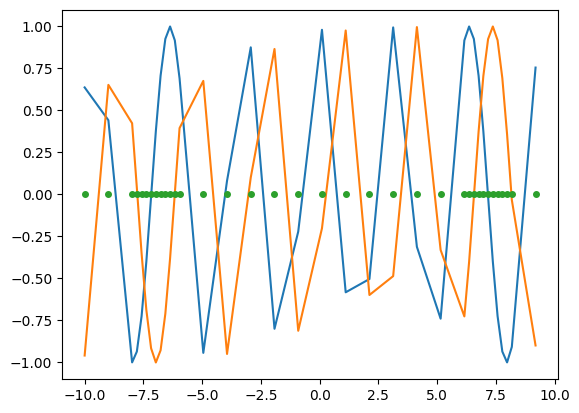

In [7]:
reduced_te_wave_function = quat.stationary_time_evolution(dispersion.k2omega(k_pw), utgrid, wave_function, mask)

plt.plot(reduced_uxgrid, np.real(reduced_te_wave_function['value'][:,0]))
plt.plot(reduced_uxgrid, np.real(reduced_te_wave_function['value'][:,10])) 
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.show()

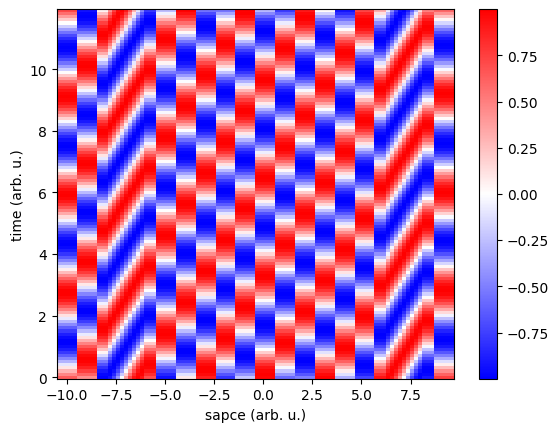

In [8]:
X,Y = np.meshgrid(reduced_uxgrid,utgrid)

Z=np.transpose(np.real(reduced_te_wave_function['value']))
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') 
plt.colorbar(pcm)
 
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.show()

# Test masking with TDSE

In [9]:
import numpy as np

uxgrid_num = 4*1024
uxgrid_dx = 0.025
uxgrid_width=uxgrid_num*uxgrid_dx
uxgrid = np.arange( -uxgrid_width/2 , uxgrid_width/2, uxgrid_dx)

print(type(uxgrid)) 
print(uxgrid_dx)
print(uxgrid_width)

<class 'numpy.ndarray'>
0.025
102.4


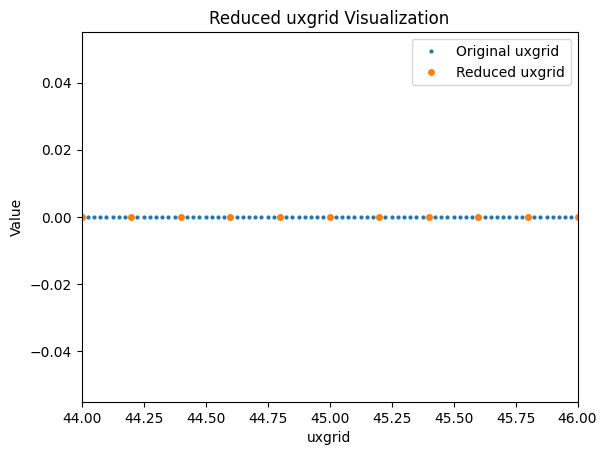

Original uxgrid length: 4096
Reduced uxgrid length: 512


In [10]:
# Desired number of points
desired_points = 512

# Calculate the step size to reduce the number of points
step_size = uxgrid_num // desired_points

# Create the mask
mask = np.zeros(uxgrid_num, dtype=bool)
mask[::step_size] = True

# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=2, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=4, label='Reduced uxgrid')
plt.xlim([44, 46])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

In [11]:
# Highlighted ranges
highlight_ranges = [(-15.5, -14.5), (14.5, 15.5)]

# Initialize mask
mask_highlight_ranges = np.zeros(uxgrid_num, dtype=bool)

# Apply mask for highlighted ranges
for start, end in highlight_ranges:
    mask_highlight_ranges |= (uxgrid >= start) & (uxgrid <= end)

# Number of highlighted points
highlighted_num = np.sum(mask_highlight_ranges)

print(f"Number of uxgrid points: {uxgrid_num}")
print(f"Number of highlighted points: {highlighted_num}")

Number of uxgrid points: 4096
Number of highlighted points: 80


In [12]:
mask += mask_highlight_ranges

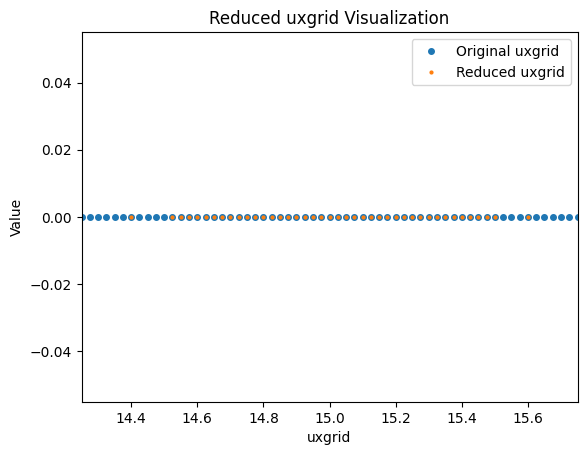

Original uxgrid length: 4096
Reduced uxgrid length: 582


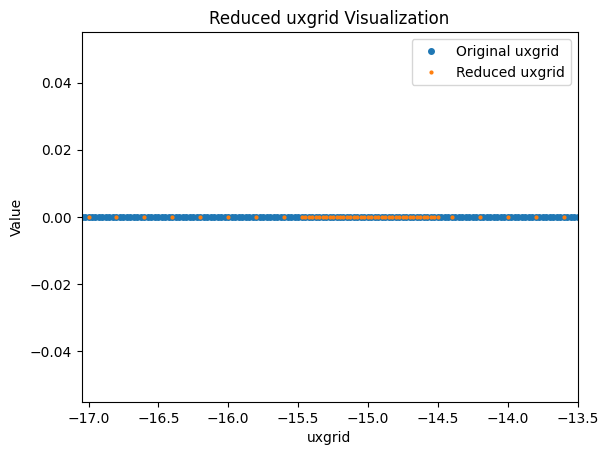

Original uxgrid length: 4096
Reduced uxgrid length: 582


In [13]:
# Create the reduced uxgrid by taking every step_size-th point
reduced_uxgrid = uxgrid[mask]

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([highlight_ranges[1][0]-10*uxgrid_dx, highlight_ranges[1][1]+10*uxgrid_dx])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Plot
plt.plot(uxgrid, np.zeros_like(uxgrid), 'o', markersize=4, label='Original uxgrid')
plt.plot(reduced_uxgrid, np.zeros_like(reduced_uxgrid), 'o', markersize=2, label='Reduced uxgrid')
plt.xlim([1.1*highlight_ranges[0][0], highlight_ranges[0][0]+2])
plt.xlabel('uxgrid')
plt.ylabel('Value')
plt.title('Reduced uxgrid Visualization')
plt.legend()
plt.show()

print("Original uxgrid length:", len(uxgrid))
print("Reduced uxgrid length:", len(reduced_uxgrid))

# Test dynamics with mask

In [14]:
import quantum_transport_toolkit as trat
import quantum_toolkit as quat
import potentials as pots
from atomic_units import hartree_atomic_unit_system as usys

ein=1.0

zeropot=pots.ZeroPotential(uxgrid)

ham_static = quat.HamiltonOperator(uxgrid,hbar=usys.hb,\
                                   me=usys.me,\
                                   charge=usys.e0,\
                                   scalarpot=zeropot,\
                                   vectorpot=zeropot )

qppk, qpmk = trat.quasiparticles_at_given_energy(ein,\
                                                 dispersion.energy2k(ein),\
                                                 ham_static)

0.0176830463875062 2.441756724855525e-05


In [15]:
utgrid, utgrid_dt = np.linspace(0,40,1000,retstep=True)
laserpot = pots.SmoothLaserPotential(uxgrid, spatial_min = -10, spatial_max = 10,\
                                            temporal_max=10,temporal_min=0,noc=3,\
                                            amplitude=0.1)

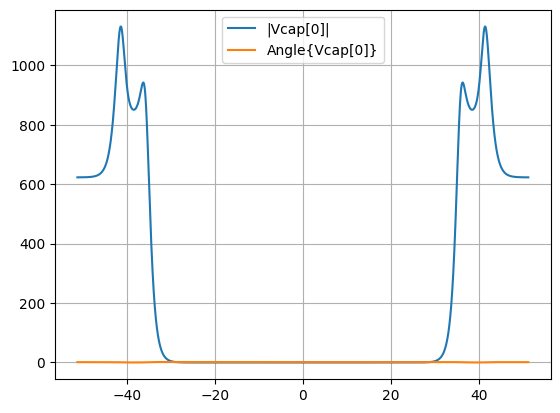

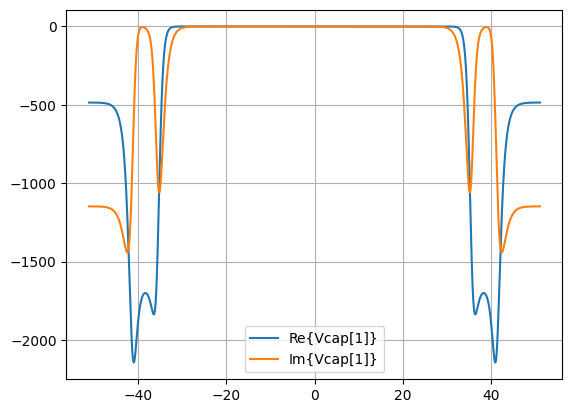

In [16]:
v_cap=quat.vcap_generator(uxgrid,param_lambda0 = 0.5)

plt.plot(uxgrid,np.abs(v_cap[0]),label="|Vcap[0]|")
plt.plot(uxgrid,np.angle(v_cap[0]),label="Angle{Vcap[0]}")
plt.legend()
plt.grid()
plt.show()

plt.plot(uxgrid,np.real(v_cap[1]),label="Re{Vcap[1]}")
plt.plot(uxgrid,np.imag(v_cap[1]),label="Im{Vcap[1]}")
plt.legend()
plt.grid()
plt.show()

# plt.plot(uxgrid_hus,np.real(v_cap_hus[2]),label="Re{Vcap[2]}")
# plt.plot(uxgrid_hus,np.imag(v_cap_hus[2]),label="Im{Vcap[2]}")
# plt.legend()
# plt.grid()
# plt.show()

In [17]:
psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/usys.hb,\
        psi0_initial = qppk["state"],\
        scalarpot = zeropot,\
        vectorpot=laserpot,\
        dt=utgrid_dt, t_start=utgrid[0], t_stop=utgrid[-1],\
        vcap=v_cap)

masked_psi_pk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qppk["energy"]/usys.hb,\
        psi0_initial = qppk["state"],\
        scalarpot = zeropot,\
        vectorpot=laserpot,\
        dt=utgrid_dt, t_start=utgrid[0], t_stop=utgrid[-1],\
        vcap=v_cap, mask=mask)

In [18]:
psi_pk_te.run()

In [19]:
masked_psi_pk_te.run()

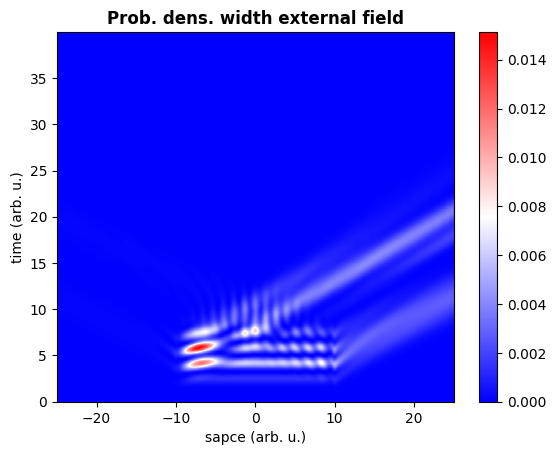

In [20]:
X,Y = np.meshgrid(uxgrid,utgrid[:-1])

Z=np.transpose(quat.probability_density(psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-25, 25])
#plt.ylim(2*laserpot.temporal_width,utgrid[-1])
plt.show()

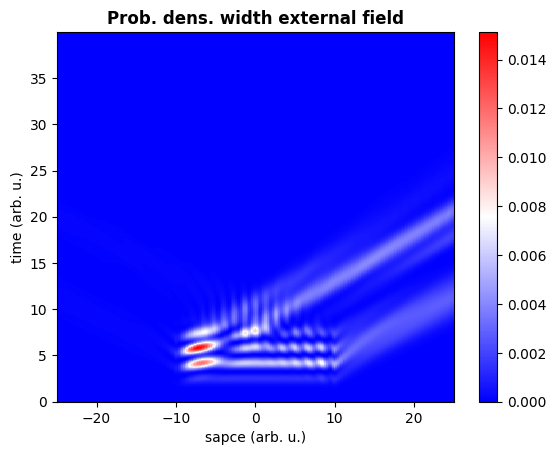

In [21]:
X,Y = np.meshgrid(reduced_uxgrid,utgrid[:-1])

Z=np.transpose(quat.probability_density(masked_psi_pk_te.psi1_time_evolution))

#z_min, z_max = -np.abs(Z).max(), np.abs(Z).max()
    
pcm = plt.pcolormesh(X,Y,Z,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
plt.xlim([-25, 25])
#plt.ylim(2*laserpot.temporal_width,utgrid[-1])
plt.show()

# Compute probability current

In [22]:
# choose masurement points on the right and the left side
meas_point_right=15
meas_point_left=-meas_point_right

In [23]:
left_index = np.abs(np.array(uxgrid) - meas_point_left).argmin()#1300
right_index = np.abs(np.array(uxgrid) - meas_point_right).argmin()#
x_left = uxgrid[left_index]
x_right = uxgrid[right_index]

print(left_index,right_index)
print(x_left,x_right)

1448 2648
-15.00000000000206 14.999999999996234


In [24]:
pc_pk=quat.probability_current(psi_pk_te.psi_time_evolution)

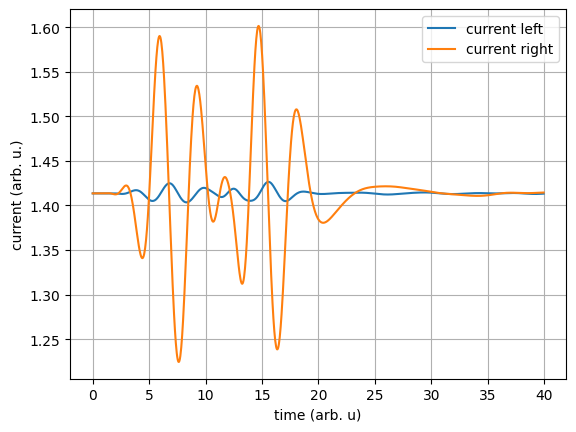

In [25]:
plt.plot(utgrid[:-1], pc_pk[left_index,:],label="current left")
plt.plot(utgrid[:-1], pc_pk[right_index,:],label="current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()

# compare with masked grid results

In [26]:
masked_pc_pk=quat.probability_current(masked_psi_pk_te.psi_time_evolution)

In [27]:
masked_left_index = np.abs(np.array(reduced_uxgrid) - meas_point_left).argmin()#1300
masked_right_index = np.abs(np.array(reduced_uxgrid) - meas_point_right).argmin()#
masked_x_left = reduced_uxgrid[masked_left_index]
masked_x_right = reduced_uxgrid[masked_right_index]

print(masked_x_left,masked_x_right)

-15.00000000000206 14.999999999996234


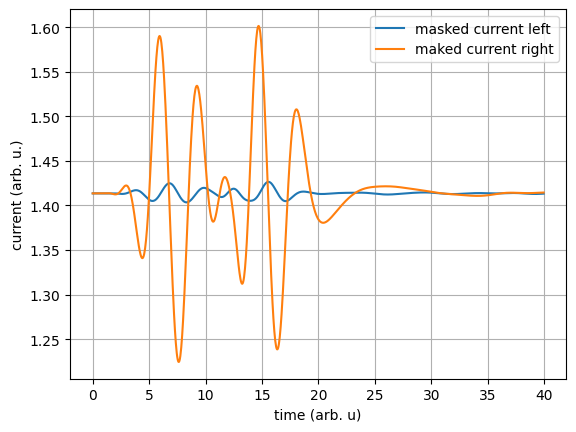

In [28]:
plt.plot(utgrid[:-1], masked_pc_pk[masked_left_index,:],label="masked current left")
plt.plot(utgrid[:-1], masked_pc_pk[masked_right_index,:],label="maked current right")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
plt.legend()
plt.grid()
plt.show()

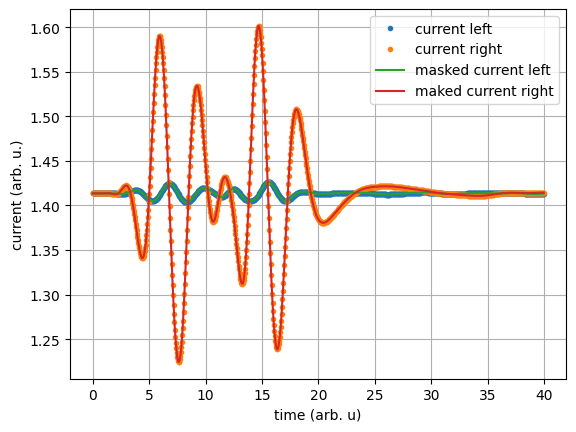

In [32]:
plt.plot(utgrid[:-1], pc_pk[left_index,:],".",label="current left")
plt.plot(utgrid[:-1], pc_pk[right_index,:],".",label="current right")
plt.plot(utgrid[:-1], masked_pc_pk[masked_left_index,:],label="masked current left")
plt.plot(utgrid[:-1], masked_pc_pk[masked_right_index,:],label="maked current right")
#plt.plot(utgrid, pcsum_diff,label="current difference")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u.)")
#plt.xlim(0,40)
plt.legend()
#plt.ylim(-1e-5,1e-5)
plt.grid()
plt.show()